# Unemployment Analysis

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
unemployment_df = pd.read_csv("Unemployment_in_india.csv")
unemployment_df

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural
...,...,...,...,...,...,...,...
763,NaN,NaN,NaN,NaN,NaN,NaN,NaN
764,NaN,NaN,NaN,NaN,NaN,NaN,NaN
765,NaN,NaN,NaN,NaN,NaN,NaN,NaN
766,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
unemployment_df.shape

(768, 7)

In [6]:
unemployment_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


In [7]:
unemployment_df.isnull().sum()

Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64

In [8]:
unemployment_df= unemployment_df.dropna().copy()
#By doing .copy() , this dataframe becomes fully independent dataframe
unemployment_df

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural
...,...,...,...,...,...,...,...
749,West Bengal,29-02-2020,Monthly,7.55,10871168.0,44.09,Urban
750,West Bengal,31-03-2020,Monthly,6.67,10806105.0,43.34,Urban
751,West Bengal,30-04-2020,Monthly,15.63,9299466.0,41.20,Urban
752,West Bengal,31-05-2020,Monthly,15.22,9240903.0,40.67,Urban


In [9]:
unemployment_df.shape

(740, 7)

In [10]:
unemployment_df.isnull().sum()

Region                                      0
 Date                                       0
 Frequency                                  0
 Estimated Unemployment Rate (%)            0
 Estimated Employed                         0
 Estimated Labour Participation Rate (%)    0
Area                                        0
dtype: int64

In [11]:
unemployment_df

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural
...,...,...,...,...,...,...,...
749,West Bengal,29-02-2020,Monthly,7.55,10871168.0,44.09,Urban
750,West Bengal,31-03-2020,Monthly,6.67,10806105.0,43.34,Urban
751,West Bengal,30-04-2020,Monthly,15.63,9299466.0,41.20,Urban
752,West Bengal,31-05-2020,Monthly,15.22,9240903.0,40.67,Urban


In [12]:
#To remove whitespces 
unemployment_df.columns = unemployment_df.columns.str.strip()
unemployment_df['Date'] = unemployment_df['Date'].str.strip()

#To tell pandas the date format
unemployment_df['Date'] = pd.to_datetime(unemployment_df['Date'], format='%d-%m-%Y')

In [13]:
# EDA
# Grouping - Region wise
region_avg = unemployment_df.groupby("Region")["Estimated Unemployment Rate (%)"].mean().sort_values(ascending=False)
region_avg

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Punjab              12.031071
Puducherry          10.215000
Kerala              10.123929
Tamil Nadu           9.284286
Goa                  9.274167
Chhattisgarh         9.240357
West Bengal          8.124643
Telangana            7.737857
Maharashtra          7.557500
Andhra Pradesh       7.477143
Madhya Pradesh       7.406429
Sikkim               7.249412
Karnataka            6.676071
Gujarat              6.663929
Uttarakhand          6.582963
Assam                6.428077
Odisha               5.657857
Meghalaya            4.798889
Name: Estimated Unemployment Rate (%), dtype: float64

In [14]:
#Grouping - Monthly wise 
month_avg = unemployment_df.groupby(unemployment_df['Date'].dt.month)["Estimated Unemployment Rate (%)"].mean()
month_avg

Date
1      9.950755
2      9.964717
3     10.700577
4     23.641569
5     16.646190
6     10.553462
7      9.033889
8      9.637925
9      9.051731
10     9.900909
11     9.868364
12     9.497358
Name: Estimated Unemployment Rate (%), dtype: float64

### Visualization 1 : The time-series plot shows unemployment rates for [state names] over time. A sharp spike is visible around April 2020 across all states, coinciding with the COVID-19 lockdown. Rates decline gradually in the following months as restrictions eased.

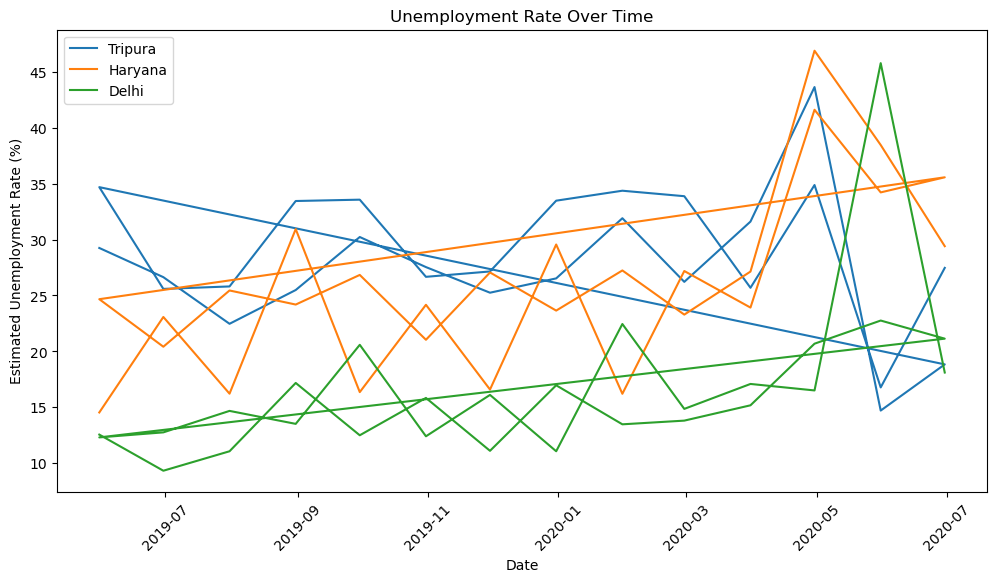

<Figure size 640x480 with 0 Axes>

In [15]:
# Visualization 1 - Time-series line chart: unemployment rate over time for at least 3 major

states_to_plot = ["Tripura", "Haryana", "Delhi"]

plt.figure(figsize=(12,6))
for state in states_to_plot:
    state_data = unemployment_df[unemployment_df["Region"] == state]
    plt.plot(state_data["Date"], state_data["Estimated Unemployment Rate (%)"], label=state)

plt.xlabel("Date")
plt.ylabel("Estimated Unemployment Rate (%)")
plt.title("Unemployment Rate Over Time")
plt.legend()
plt.xticks(rotation=45)
plt.show()
plt.tight_layout()

### Visualization 2 : Tripura and Haryana have the highest average unemployment rates among all regions, at 28.35% and 26.28% respectively — well above the rest of the top 10. This suggests these states faced persistently higher joblessness compared to the national spread.

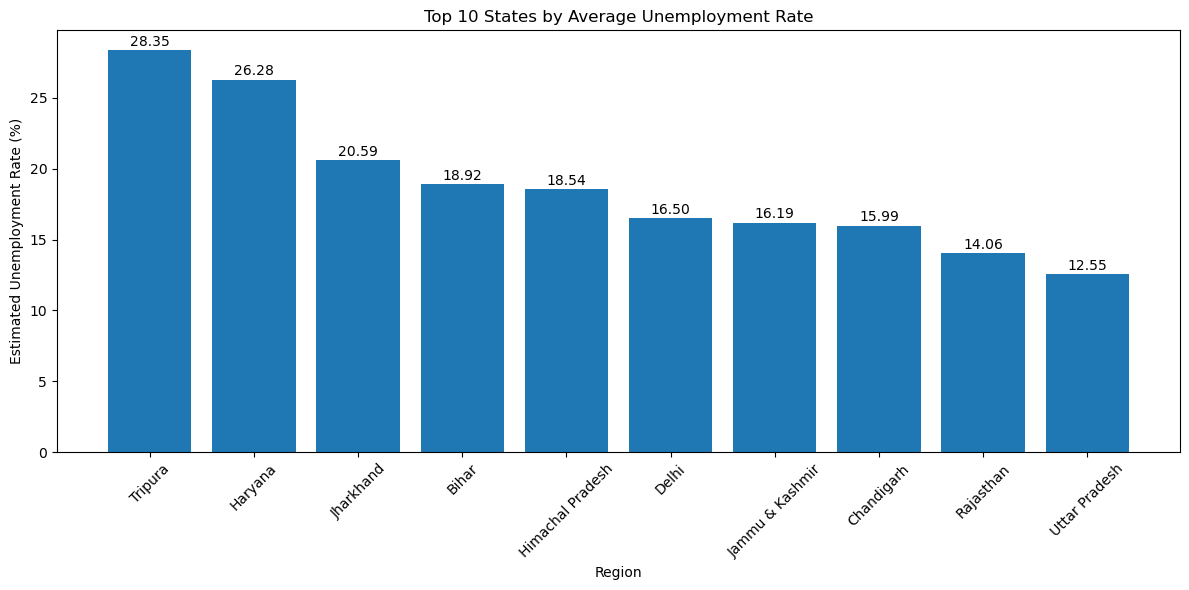

In [16]:
# Visualization 2 : top 10 states with highest average unemployment rate

region_avg_top10 = region_avg.head(10)

plt.figure(figsize=(12,6))

x = region_avg_top10.index
y = region_avg_top10.values

plt.bar(x,y)
plt.xlabel("Region")
plt.ylabel("Estimated Unemployment Rate (%)")
plt.title("Top 10 States by Average Unemployment Rate")
plt.xticks(rotation=45)
plt.tight_layout()

for i in range(len(x)):
    plt.text(x[i], y[i]+0.3, f"{y[i]:.2f}", ha="center")

### Visualization 3 : Estimated Unemployment Rate shows a weak negative correlation with Estimated Employed (-0.22), meaning higher unemployment rates are mildly associated with fewer people employed — as expected, but not a strong relationship in this dataset. Unemployment Rate and Labour Participation Rate show almost no correlation (0.00), suggesting the rate at which people are participating in the labour force doesn't strongly influence the unemployment rate directly.

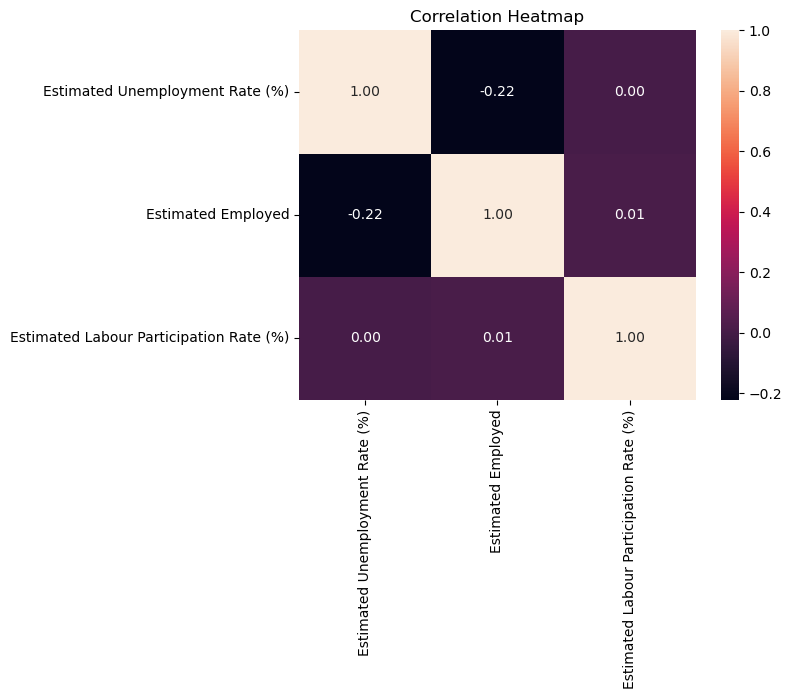

In [17]:
# Visualization 3 : correlation between unemployment rate, employment rate, and labour participation rate

corr = unemployment_df[["Estimated Unemployment Rate (%)", "Estimated Employed", "Estimated Labour Participation Rate (%)"]].corr()
sns.heatmap(corr,
            annot=True,
            fmt=".2f")

plt.title('Correlation Heatmap')
plt.show()

## Pre-Covid VS Post-Covid Comparison

In [18]:
pre_covid = unemployment_df[unemployment_df["Date"] < "2020-03-01"]
post_covid = unemployment_df[unemployment_df["Date"] >= "2020-03-01"]

pre_avg = pre_covid["Estimated Unemployment Rate (%)"].mean()
post_avg = post_covid["Estimated Unemployment Rate (%)"].mean()

print(f"Pre-COVID average unemployment rate: {pre_avg:.2f}%")
print(f"Post-COVID average unemployment rate: {post_avg:.2f}%")

Pre-COVID average unemployment rate: 9.51%
Post-COVID average unemployment rate: 17.77%


## Conclusion
### 1. Regional disparity: Tripura (28.35%) and Haryana (26.28%) recorded the highest average unemployment rates, far above the national spread, while Meghalaya (4.80%) and Odisha (5.66%) recorded the lowest — indicating unemployment in India is not uniform but heavily concentrated in specific states.
### 2. COVID-19 impact on monthly trends: Month-wise analysis showed a sharp spike in April 2020 (23.64%), coinciding with India's nationwide lockdown, with elevated rates continuing into May (16.65%) before gradually declining.
### 3. Pre vs. post-COVID: Average unemployment rate rose from 9.51% before COVID-19 to 17.77% after — nearly double — confirming the pandemic caused a substantial, measurable disruption to employment across India.
### 4. Correlation findings: Unemployment rate showed a weak negative correlation with employed count (-0.22) and virtually no correlation with labour participation rate (0.00), suggesting unemployment during this period was driven more by external shocks (like COVID-19) than by underlying shifts in labour force participation.
### 5. Overall: The data confirms that India's unemployment crisis during 2020 was sharply timed around the lockdown period and disproportionately affected certain states, rather than being a gradual, evenly distributed trend.